# Model-Based Control and Robustness Analysis for a 5-DOF Robotic Manipulator

This notebook develops a simulation framework for a 5-DOF serial robotic manipulator and uses it to compare classical joint-space controllers under uncertainty and external disturbances.

The main goals of this project are:

- to model the manipulator kinematics and simplified dynamics,
- to generate feasible joint trajectories for a desired end-effector motion,
- to implement and compare multiple controllers,
- to evaluate tracking performance, control effort, and robustness.

The simulation is structured to reflect a systems-level robotics workflow: model formulation, trajectory generation, control design, numerical integration, and performance benchmarking.



In [37]:
import os
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["figure.dpi"] = 120

## Configuration and model parameters

This section defines the simulation settings, manipulator geometric parameters, simplified physical parameters, and controller gains.

### Simulation parameters
The time step `DT` and final simulation time `T_FINAL` determine the time discretization of the simulation. A small step size is chosen so that the numerical integration remains stable and the controller response is well resolved.

### Manipulator geometry
The manipulator is represented as a 5-DOF serial revolute chain using Denavit–Hartenberg (DH) parameters. Each row of `DH_PARAMS` defines one link transform through the parameters:

- `a`: link length,
- `alpha`: link twist,
- `d`: link offset,
- `theta_offset`: fixed angular offset.

### Physical parameters
The link masses, link lengths, joint inertias, and viscous friction coefficients are simplified but structured so that the simulator captures the main effects of inertia, gravity, damping, and joint coupling.

### Initial conditions
`Q0` and `QDOT0` define the initial joint positions and velocities of the manipulator.

### Controller gains
Two gain sets are defined:
- one for PD-based controllers,
- one for computed torque control.

The gains are selected to provide stable trajectory tracking while keeping the control effort within a reasonable range.

In [ ]:
DT = 0.002
T_FINAL = 6.0
N_STEPS = int(T_FINAL / DT)

DH_PARAMS = [
    [0.0,      np.pi/2,  0.12, 0.0],
    [0.30,     0.0,      0.00, 0.0],
    [0.25,     0.0,      0.00, 0.0],
    [0.0,      np.pi/2,  0.00, 0.0],
    [0.0,      0.0,      0.12, 0.0],
]

LINK_MASSES = np.array([4.0, 3.5, 2.5, 1.5, 0.8])
LINK_LENGTHS = np.array([0.12, 0.30, 0.25, 0.10, 0.12])

INERTIA_DIAG = np.array([1.5, 1.2, 0.8, 0.25, 0.12])
FRICTION = np.array([0.8, 0.7, 0.5, 0.2, 0.1])

GRAVITY = 9.81

Q0 = np.array([0.0, -0.6, 1.0, 0.2, 0.0])
QDOT0 = np.zeros(5)

KP_PD = np.diag([120, 140, 120, 60, 40])
KD_PD = np.diag([20,  24,  20, 10,  8])

KP_CT = np.diag([100, 120, 100, 50, 35])
KD_CT = np.diag([18,  20,  18,  8,  6])

## Forward kinematics and Jacobian

This section implements the manipulator kinematics.

### Forward kinematics
Forward kinematics maps the joint configuration \( q \) to the end-effector pose in Cartesian space. For a serial manipulator, the pose of the end-effector is obtained by multiplying the homogeneous transformation matrices of all links:

\[
T_0^n(q) = A_1(q_1) A_2(q_2) \cdots A_n(q_n)
\]

Each transformation matrix is built using the Denavit–Hartenberg convention.

The forward kinematics function returns the cumulative transformation of each joint frame, which is useful not only for computing the end-effector position but also for constructing the Jacobian.

### End-effector position
For this project, the main task is position tracking rather than full pose tracking. Therefore, the end-effector position is extracted from the final homogeneous transformation matrix.

### Geometric Jacobian
The geometric Jacobian describes how joint velocities map to end-effector linear and angular velocities:

\[
\dot{x} = J(q)\dot{q}
\]

For a revolute joint, the linear and angular Jacobian columns are:

\[
J_{v,i} = z_{i-1} \times (o_n - o_{i-1}), \qquad
J_{\omega,i} = z_{i-1}
\]

where:
- \( z_{i-1} \) is the axis of rotation of joint \( i \),
- \( o_{i-1} \) is the origin of frame \( i-1 \),
- \( o_n \) is the end-effector origin.

The Jacobian is essential for inverse kinematics and for understanding velocity-level manipulator behavior.

In [39]:
def dh_transform(a, alpha, d, theta):
    ct, st = np.cos(theta), np.sin(theta)
    ca, sa = np.cos(alpha), np.sin(alpha)

    return np.array([
        [ct, -st*ca,  st*sa, a*ct],
        [st,  ct*ca, -ct*sa, a*st],
        [0.0,    sa,     ca,    d],
        [0.0,   0.0,    0.0,  1.0]
    ])

def forward_kinematics(q, dh_params):
    T = np.eye(4)
    Ts = [T.copy()]
    for i, qi in enumerate(q):
        a, alpha, d, theta_offset = dh_params[i]
        A = dh_transform(a, alpha, d, qi + theta_offset)
        T = T @ A
        Ts.append(T.copy())
    return Ts

def end_effector_position(q, dh_params):
    Ts = forward_kinematics(q, dh_params)
    return Ts[-1][:3, 3]

def jacobian_geometric(q, dh_params):
    Ts = forward_kinematics(q, dh_params)
    n = len(q)
    o_n = Ts[-1][:3, 3]

    Jv = np.zeros((3, n))
    Jw = np.zeros((3, n))

    for i in range(n):
        z_i = Ts[i][:3, 2]
        o_i = Ts[i][:3, 3]
        Jv[:, i] = np.cross(z_i, o_n - o_i)
        Jw[:, i] = z_i

    return np.vstack((Jv, Jw))

def ik_damped_least_squares(
    x_target, q_init, dh_params, 
    max_iters=300, alpha=0.5, damping=1e-3, tol=1e-4
):
    q = q_init.copy()

    for _ in range(max_iters):
        x = end_effector_position(q, dh_params)
        e = x_target - x
        if np.linalg.norm(e) < tol:
            break

        J = jacobian_geometric(q, dh_params)[:3, :]
        JJt = J @ J.T
        dq = J.T @ np.linalg.solve(JJt + (damping**2)*np.eye(3), e)
        q = q + alpha * dq

    return q

In [40]:
def cubic_time_scaling(t, T):
    s = 3*(t/T)**2 - 2*(t/T)**3
    sd = 6*t/T**2 - 6*t**2/T**3
    sdd = 6/T**2 - 12*t/T**3
    return s, sd, sdd

def joint_trajectory(q_start, q_goal, t_vec):
    T = t_vec[-1]
    n = len(t_vec)
    dof = len(q_start)

    qd = np.zeros((n, dof))
    qd_dot = np.zeros((n, dof))
    qd_ddot = np.zeros((n, dof))

    dq = q_goal - q_start

    for k, t in enumerate(t_vec):
        s, sd, sdd = cubic_time_scaling(t, T)
        qd[k] = q_start + s * dq
        qd_dot[k] = sd * dq
        qd_ddot[k] = sdd * dq

    return qd, qd_dot, qd_ddot

In [41]:
def mass_matrix(q, inertia_diag):
    n = len(q)
    M = np.diag(inertia_diag + 0.15*np.abs(np.cos(q)))
    for i in range(n-1):
        coupling = 0.03*np.cos(q[i] - q[i+1])
        M[i, i+1] = coupling
        M[i+1, i] = coupling
    return M

def coriolis_vector(q, qdot):
    n = len(q)
    c = np.zeros(n)
    for i in range(n):
        c[i] = 0.05*np.sin(q[i]) * qdot[i]
    for i in range(n-1):
        c[i] += 0.02*(qdot[i+1]**2)*np.sin(q[i] - q[i+1])
    return c

def gravity_vector(q, link_masses, link_lengths, g=9.81):
    n = len(q)
    G = np.zeros(n)

    for i in range(n):
        torque_i = 0.0
        for j in range(i, n):
            accum_angle = np.sum(q[:j+1])
            lever = 0.5*link_lengths[j] if j == i else link_lengths[j]
            torque_i += link_masses[j] * g * lever * np.cos(accum_angle)
        G[i] = torque_i

    return G

def friction_vector(qdot, friction):
    return friction * qdot

def forward_dynamics(q, qdot, tau, inertia_diag, link_masses, link_lengths, friction, disturbance=None):
    if disturbance is None:
        disturbance = np.zeros_like(q)

    M = mass_matrix(q, inertia_diag)
    C = coriolis_vector(q, qdot)
    G = gravity_vector(q, link_masses, link_lengths)
    F = friction_vector(qdot, friction)

    qdd = np.linalg.solve(M, tau + disturbance - C - G - F)
    return qdd

def rk4_step(q, qdot, tau, dt, inertia_diag, link_masses, link_lengths, friction, disturbance=None):
    def f(state):
        qq = state[:len(q)]
        qd = state[len(q):]
        qdd = forward_dynamics(
            qq, qd, tau, inertia_diag, link_masses, link_lengths, friction, disturbance
        )
        return np.hstack((qd, qdd))

    x = np.hstack((q, qdot))
    k1 = f(x)
    k2 = f(x + 0.5*dt*k1)
    k3 = f(x + 0.5*dt*k2)
    k4 = f(x + dt*k3)

    x_next = x + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)
    return x_next[:len(q)], x_next[len(q):]

## Controller design

This section implements three joint-space controllers.

The purpose is to compare controllers of increasing model sophistication and evaluate how model knowledge affects tracking performance and robustness.

### 1. PD control
The proportional-derivative controller is:

\[
\tau = K_p(q_d - q) + K_d(\dot{q}_d - \dot{q})
\]

This controller uses only tracking error and velocity error. It is simple and widely used, but it does not explicitly account for gravity or nonlinear dynamics.

### 2. PD control with gravity compensation
To improve performance, the gravity term is added:

\[
\tau = K_p e + K_d \dot{e} + G(q)
\]

This reduces the burden on the feedback loop by compensating for gravitational loading, which is especially important for manipulators with heavy proximal links or large configuration changes.

### 3. Computed torque control
Computed torque control uses the manipulator model to cancel the nonlinear dynamics and impose approximately linear closed-loop error dynamics:

\[
\tau = M(q)\left(\ddot{q}_d + K_d\dot{e} + K_p e\right) + C(q,\dot{q}) + G(q)
\]

This controller is more model-dependent than PD control, but under accurate modeling it typically provides better tracking performance.

### Why compare these controllers?
This comparison reflects a real robotics engineering question:

- How much performance is gained by incorporating more model knowledge?
- How sensitive is model-based control to plant uncertainty and disturbances?
- What is the tradeoff between simplicity, robustness, and tracking accuracy?

In [42]:
def pd_control(q, qdot, qd, qd_dot, Kp, Kd):
    e = qd - q
    edot = qd_dot - qdot
    tau = Kp @ e + Kd @ edot
    return tau

def pd_gravity_control(q, qdot, qd, qd_dot, Kp, Kd, link_masses, link_lengths):
    e = qd - q
    edot = qd_dot - qdot
    G = gravity_vector(q, link_masses, link_lengths)
    tau = Kp @ e + Kd @ edot + G
    return tau

def computed_torque_control(
    q, qdot, qd, qd_dot, qd_ddot, 
    Kp, Kd, inertia_diag, link_masses, link_lengths
):
    e = qd - q
    edot = qd_dot - qdot

    M = mass_matrix(q, inertia_diag)
    C = coriolis_vector(q, qdot)
    G = gravity_vector(q, link_masses, link_lengths)

    v = qd_ddot + Kd @ edot + Kp @ e
    tau = M @ v + C + G
    return tau

In [43]:
def run_simulation(
    controller_fn,
    q0, qdot0,
    qd_traj, qd_dot_traj, qd_ddot_traj,
    dt,
    inertia_diag, link_masses, link_lengths, friction,
    dh_params,
    disturbance_profile=None
):
    N = qd_traj.shape[0]
    dof = len(q0)

    q = q0.copy()
    qdot = qdot0.copy()

    q_hist = np.zeros((N, dof))
    qdot_hist = np.zeros((N, dof))
    tau_hist = np.zeros((N, dof))
    ee_hist = np.zeros((N, 3))
    err_hist = np.zeros((N, dof))

    for k in range(N):
        qd = qd_traj[k]
        qd_dot = qd_dot_traj[k]
        qd_ddot = qd_ddot_traj[k]

        tau = controller_fn(q, qdot, qd, qd_dot, qd_ddot)

        disturbance = np.zeros(dof)
        if disturbance_profile is not None:
            disturbance = disturbance_profile(k)

        q, qdot = rk4_step(
            q, qdot, tau, dt,
            inertia_diag, link_masses, link_lengths, friction,
            disturbance=disturbance
        )

        q_hist[k] = q
        qdot_hist[k] = qdot
        tau_hist[k] = tau
        ee_hist[k] = end_effector_position(q, dh_params)
        err_hist[k] = qd - q

    return {
        "q": q_hist,
        "qdot": qdot_hist,
        "tau": tau_hist,
        "ee": ee_hist,
        "err": err_hist
    }

In [44]:
def compute_metrics(q_ref, q_hist, tau_hist, ee_ref, ee_hist, dt):
    joint_rms = np.sqrt(np.mean((q_ref - q_hist)**2))
    ee_rms = np.sqrt(np.mean(np.sum((ee_ref - ee_hist)**2, axis=1)))
    max_tau = np.max(np.abs(tau_hist))
    effort = np.sum(np.sum(tau_hist**2, axis=1)) * dt

    return {
        "joint_rms_error": float(joint_rms),
        "ee_rms_error": float(ee_rms),
        "max_abs_torque": float(max_tau),
        "torque_energy": float(effort)
    }

def plot_joint_tracking(t, q_ref, q_hist, label):
    dof = q_ref.shape[1]
    for i in range(dof):
        plt.figure()
        plt.plot(t, q_ref[:, i], label=f"q{i+1} desired")
        plt.plot(t, q_hist[:, i], "--", label=f"q{i+1} actual")
        plt.xlabel("Time (s)")
        plt.ylabel("Angle (rad)")
        plt.title(f"{label} - Joint {i+1} Tracking")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        filename = f"results/{label}_joint_{i+1}.png"
        plt.savefig(filename, dpi=200)
        plt.show()

def plot_ee_path(ee_ref, ee_hist, label):
    plt.figure()
    plt.plot(ee_ref[:, 0], ee_ref[:, 1], "--", label="Desired EE path")
    plt.plot(ee_hist[:, 0], ee_hist[:, 1], label="Actual EE path")
    plt.xlabel("x (m)")
    plt.ylabel("y (m)")
    plt.title(f"{label} - End-Effector Path")
    plt.axis("equal")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig("results/End-Effector_Path.png", dpi=200)
    plt.show()

def plot_torque(t, tau_hist, label):
    plt.figure()
    for i in range(tau_hist.shape[1]):
        plt.plot(t, tau_hist[:, i], label=f"tau{i+1}")
    plt.xlabel("Time (s)")
    plt.ylabel("Torque (Nm)")
    plt.title(f"{label} - Joint Torques")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig("results/Joint_Torques.png", dpi=200)
    plt.show()

In [45]:
t = np.linspace(0, T_FINAL, N_STEPS)

x0 = end_effector_position(Q0, DH_PARAMS)
x_goal = x0 + np.array([0.10, 0.15, -0.05])

q_goal = ik_damped_least_squares(x_goal, Q0.copy(), DH_PARAMS)

print("Initial EE position:", x0)
print("Goal EE position:", x_goal)
print("Solved q_goal:", q_goal)

qd, qd_dot, qd_ddot = joint_trajectory(Q0, q_goal, t)
ee_ref = np.array([end_effector_position(qd[k], DH_PARAMS) for k in range(len(t))])

Initial EE position: [ 5.45623030e-01 -1.78234134e-17 -5.10784302e-02]
Goal EE position: [ 0.64562303  0.15       -0.10107843]
Solved q_goal: [ 2.28283723e-01  7.00440820e+00 -1.52704605e+00  1.30217191e+01
 -5.08982523e-16]


In [46]:
def disturbance_profile(k):
    tau_d = np.zeros(5)
    if int(2.0/DT) <= k <= int(2.4/DT):
        tau_d[1] = 4.0
        tau_d[2] = -3.0
    return tau_d

In [47]:
ctrl_pd = lambda q, qdot, qd_k, qd_dot_k, qd_ddot_k: pd_control(
    q, qdot, qd_k, qd_dot_k, KP_PD, KD_PD
)

results_pd = run_simulation(
    controller_fn=ctrl_pd,
    q0=Q0,
    qdot0=QDOT0,
    qd_traj=qd,
    qd_dot_traj=qd_dot,
    qd_ddot_traj=qd_ddot,
    dt=DT,
    inertia_diag=INERTIA_DIAG,
    link_masses=LINK_MASSES,
    link_lengths=LINK_LENGTHS,
    friction=FRICTION,
    dh_params=DH_PARAMS,
    disturbance_profile=disturbance_profile
)

metrics_pd = compute_metrics(qd, results_pd["q"], results_pd["tau"], ee_ref, results_pd["ee"], DT)
metrics_pd

{'joint_rms_error': 0.05579805038097999,
 'ee_rms_error': 0.06283589591426242,
 'max_abs_torque': 21.679139431963,
 'torque_energy': 1595.536564376838}

In [48]:
ctrl_pdg = lambda q, qdot, qd_k, qd_dot_k, qd_ddot_k: pd_gravity_control(
    q, qdot, qd_k, qd_dot_k, KP_PD, KD_PD, LINK_MASSES, LINK_LENGTHS
)

results_pdg = run_simulation(
    controller_fn=ctrl_pdg,
    q0=Q0,
    qdot0=QDOT0,
    qd_traj=qd,
    qd_dot_traj=qd_dot,
    qd_ddot_traj=qd_ddot,
    dt=DT,
    inertia_diag=INERTIA_DIAG,
    link_masses=LINK_MASSES,
    link_lengths=LINK_LENGTHS,
    friction=FRICTION,
    dh_params=DH_PARAMS,
    disturbance_profile=disturbance_profile
)

metrics_pdg = compute_metrics(qd, results_pdg["q"], results_pdg["tau"], ee_ref, results_pdg["ee"], DT)
metrics_pdg

{'joint_rms_error': 0.005528885151222141,
 'ee_rms_error': 0.004129217950401945,
 'max_abs_torque': 18.632683994238906,
 'torque_energy': 1517.4618241626333}

In [49]:
ctrl_ct = lambda q, qdot, qd_k, qd_dot_k, qd_ddot_k: computed_torque_control(
    q, qdot, qd_k, qd_dot_k, qd_ddot_k, KP_CT, KD_CT,
    INERTIA_DIAG, LINK_MASSES, LINK_LENGTHS
)

results_ct = run_simulation(
    controller_fn=ctrl_ct,
    q0=Q0,
    qdot0=QDOT0,
    qd_traj=qd,
    qd_dot_traj=qd_dot,
    qd_ddot_traj=qd_ddot,
    dt=DT,
    inertia_diag=INERTIA_DIAG,
    link_masses=LINK_MASSES,
    link_lengths=LINK_LENGTHS,
    friction=FRICTION,
    dh_params=DH_PARAMS,
    disturbance_profile=disturbance_profile
)

metrics_ct = compute_metrics(qd, results_ct["q"], results_ct["tau"], ee_ref, results_ct["ee"], DT)
metrics_ct

{'joint_rms_error': 0.011468695787767429,
 'ee_rms_error': 0.0039607086854997935,
 'max_abs_torque': 18.616457908071045,
 'torque_energy': 1511.1065787387379}

In [50]:
print("PD:", metrics_pd)
print("PD + Gravity:", metrics_pdg)
print("Computed Torque:", metrics_ct)

PD: {'joint_rms_error': 0.05579805038097999, 'ee_rms_error': 0.06283589591426242, 'max_abs_torque': 21.679139431963, 'torque_energy': 1595.536564376838}
PD + Gravity: {'joint_rms_error': 0.005528885151222141, 'ee_rms_error': 0.004129217950401945, 'max_abs_torque': 18.632683994238906, 'torque_energy': 1517.4618241626333}
Computed Torque: {'joint_rms_error': 0.011468695787767429, 'ee_rms_error': 0.0039607086854997935, 'max_abs_torque': 18.616457908071045, 'torque_energy': 1511.1065787387379}


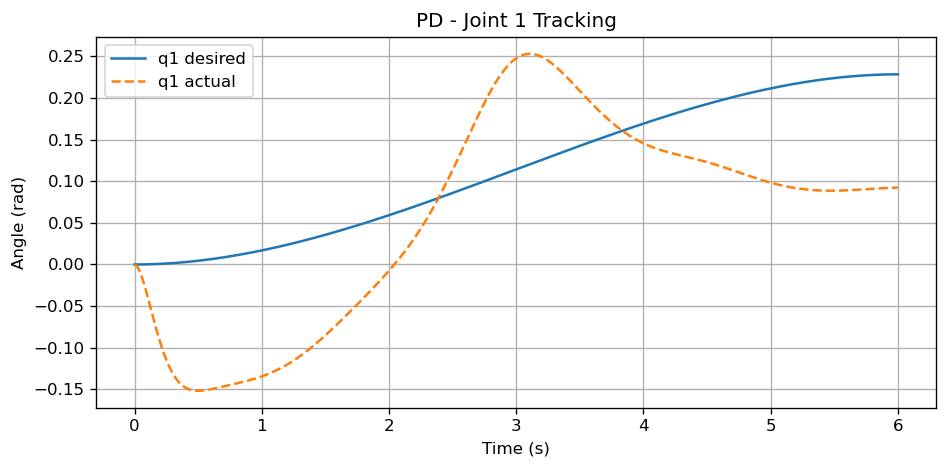

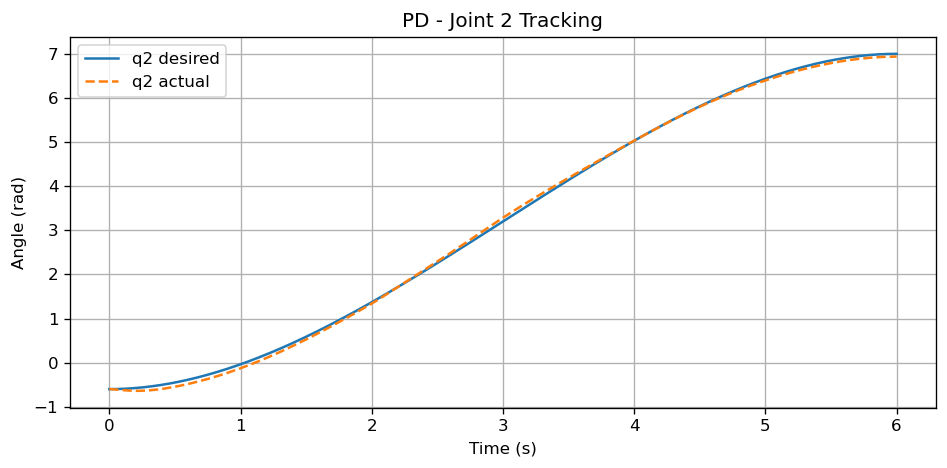

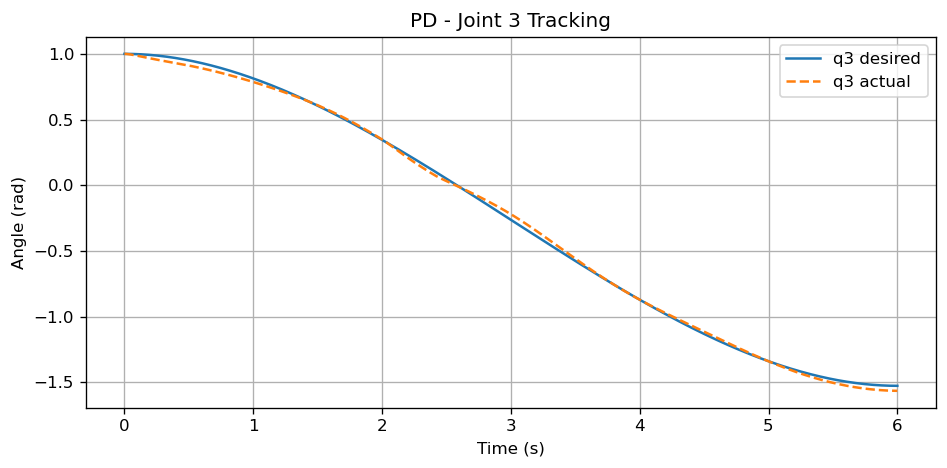

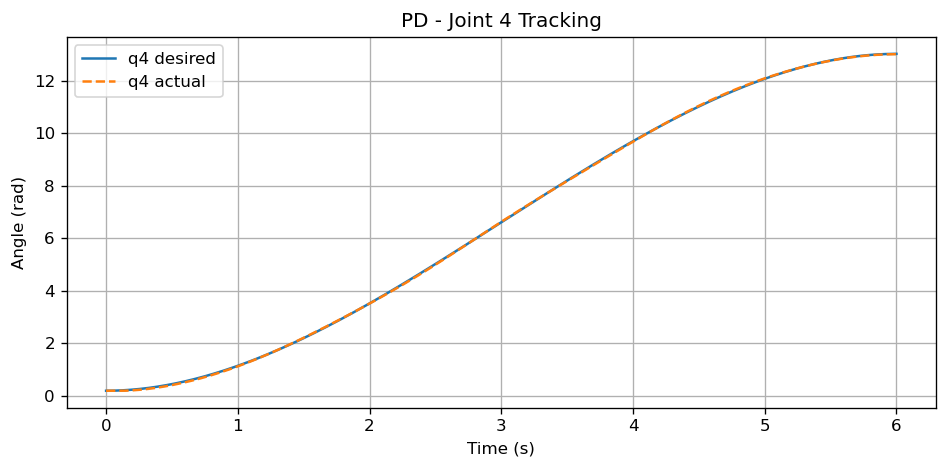

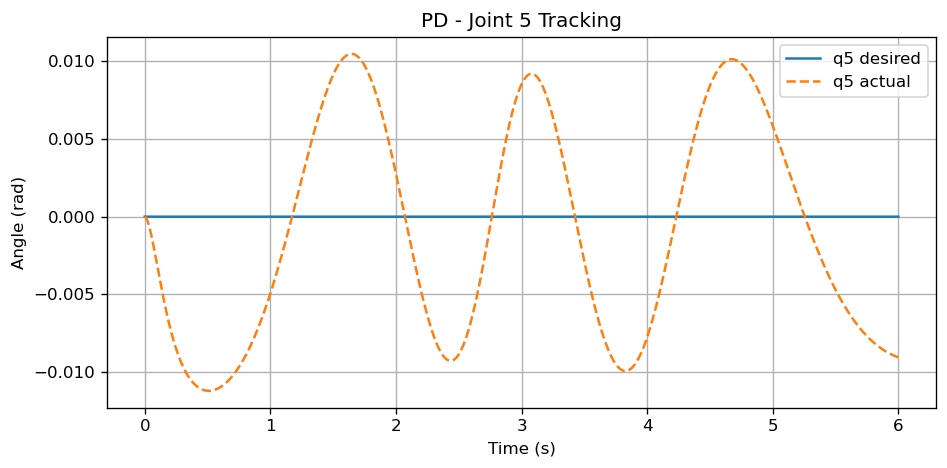

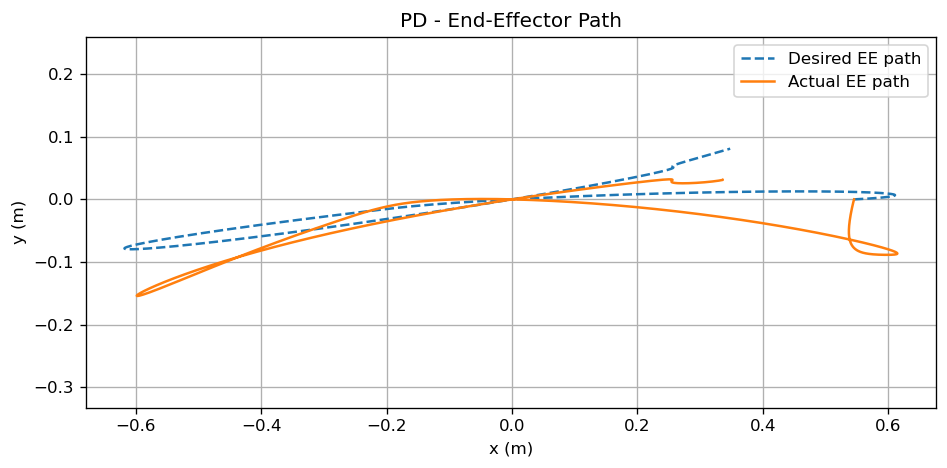

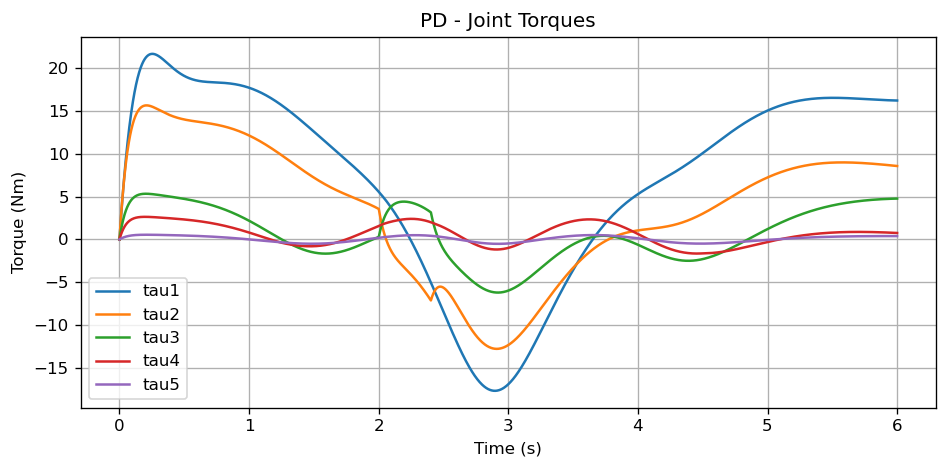

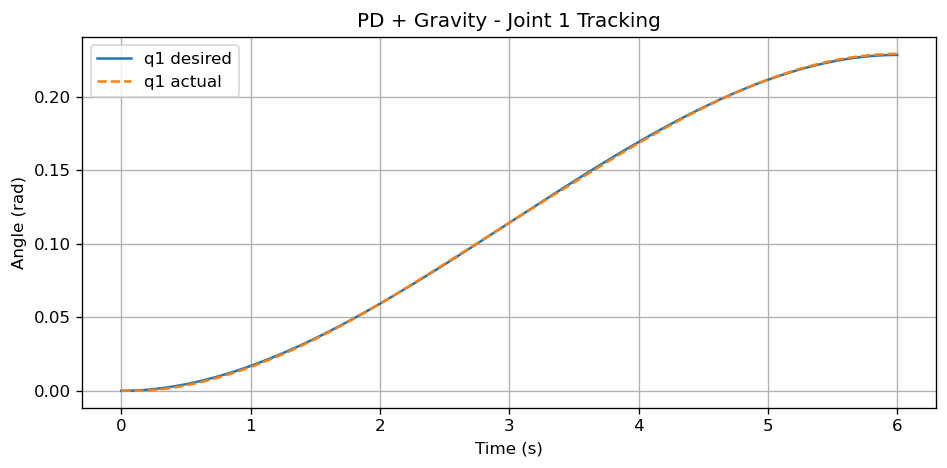

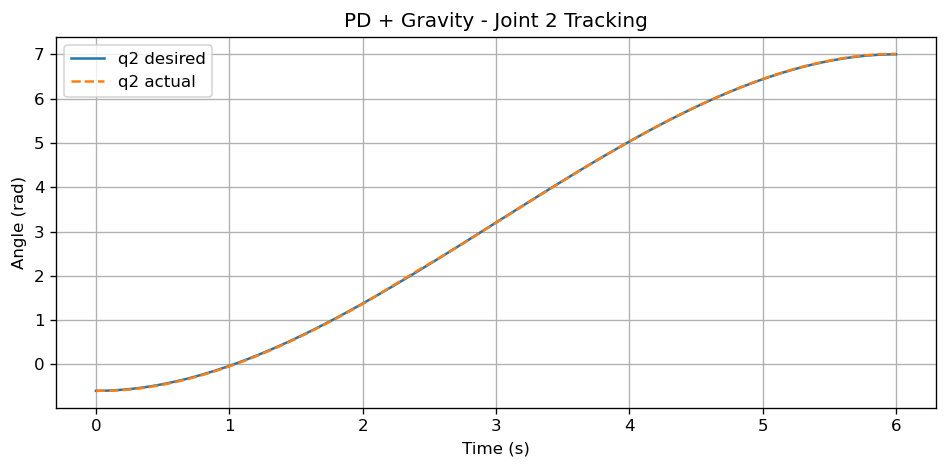

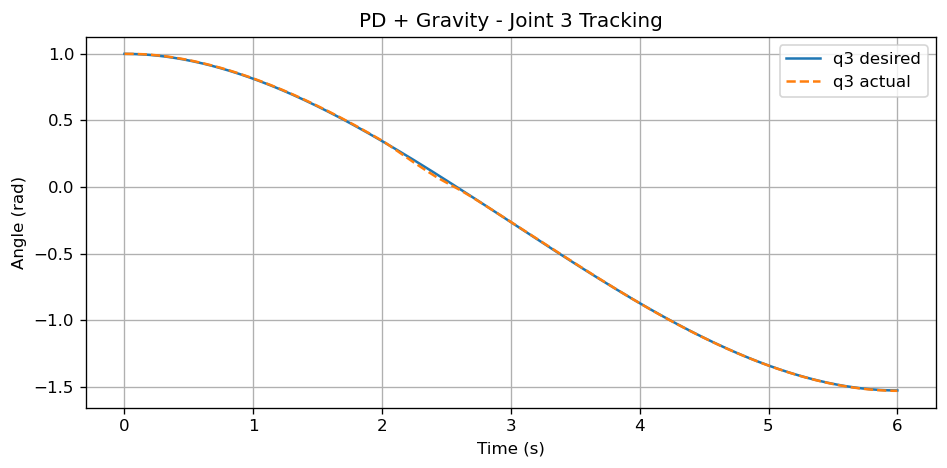

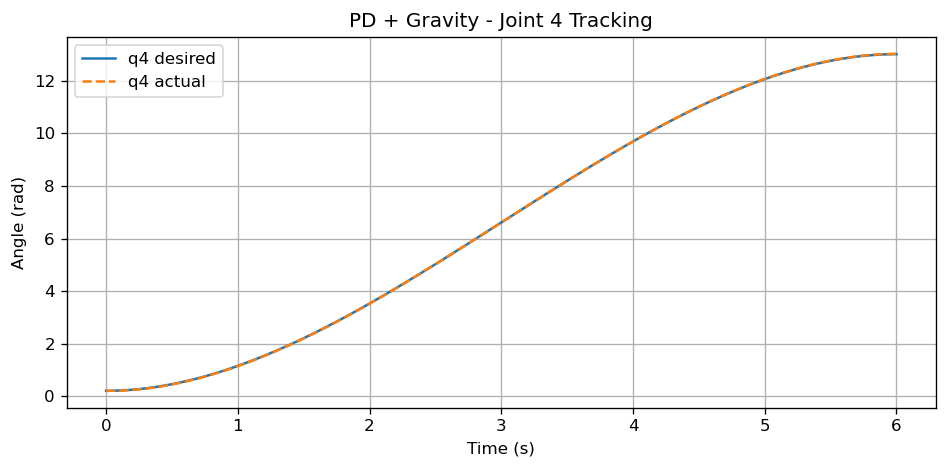

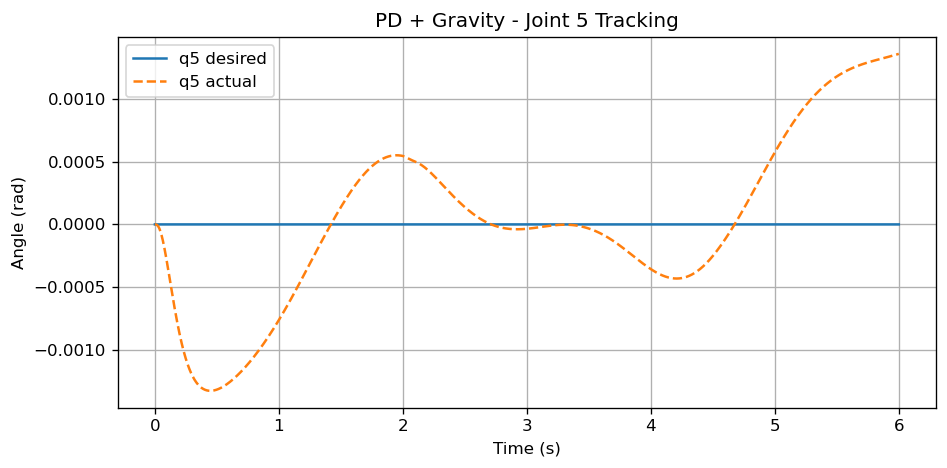

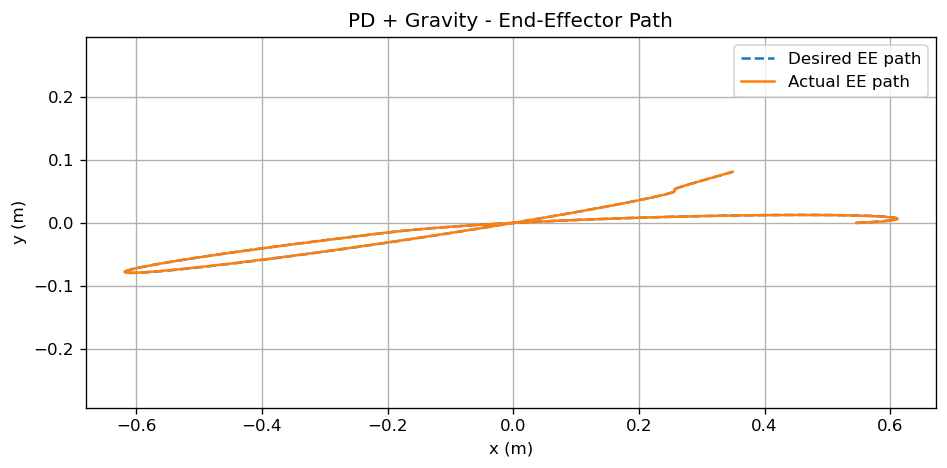

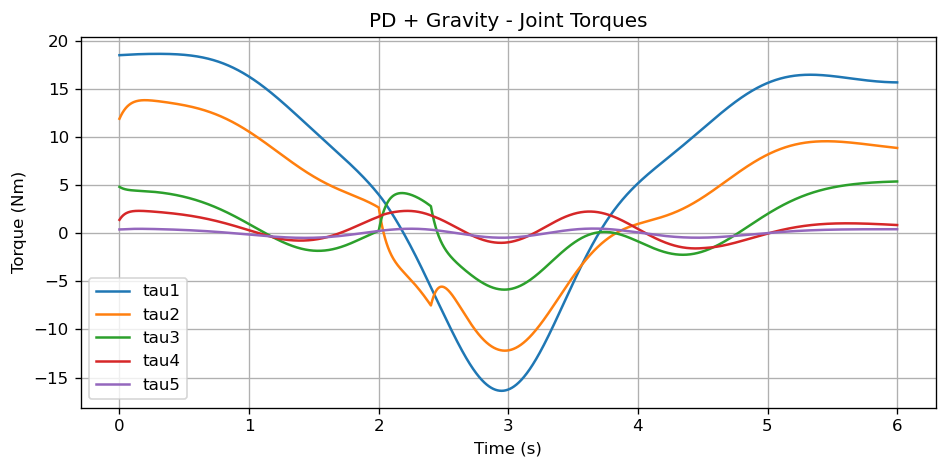

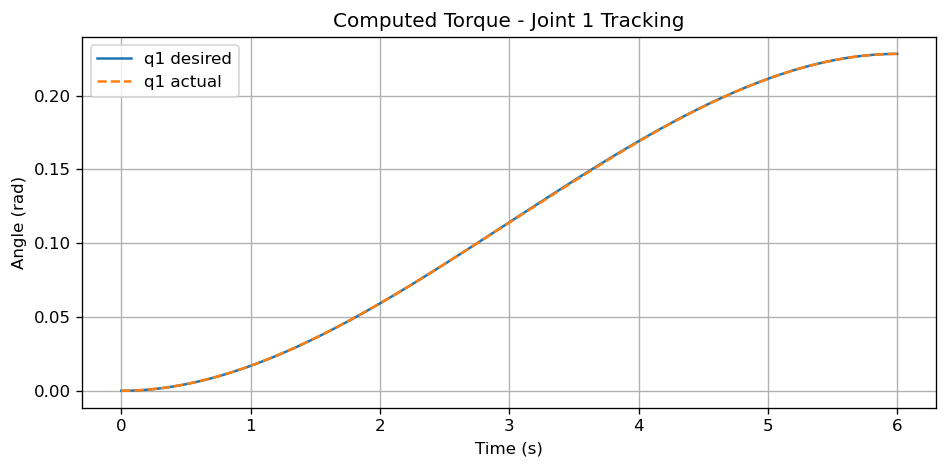

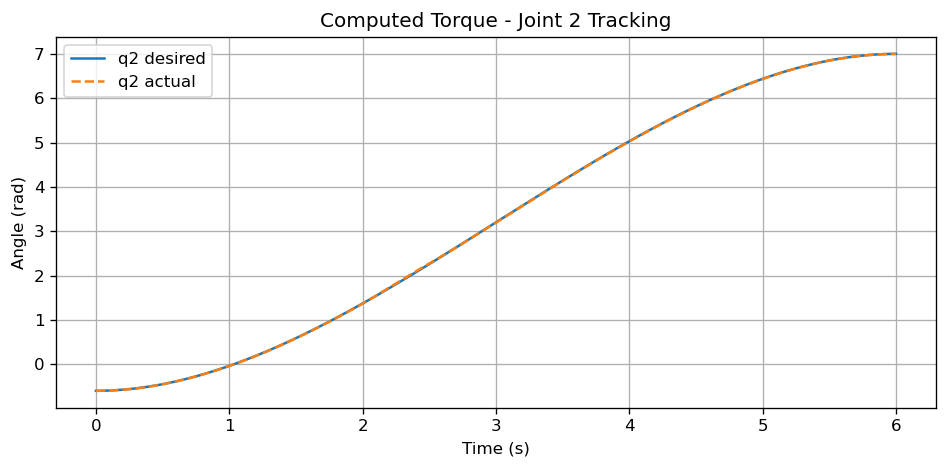

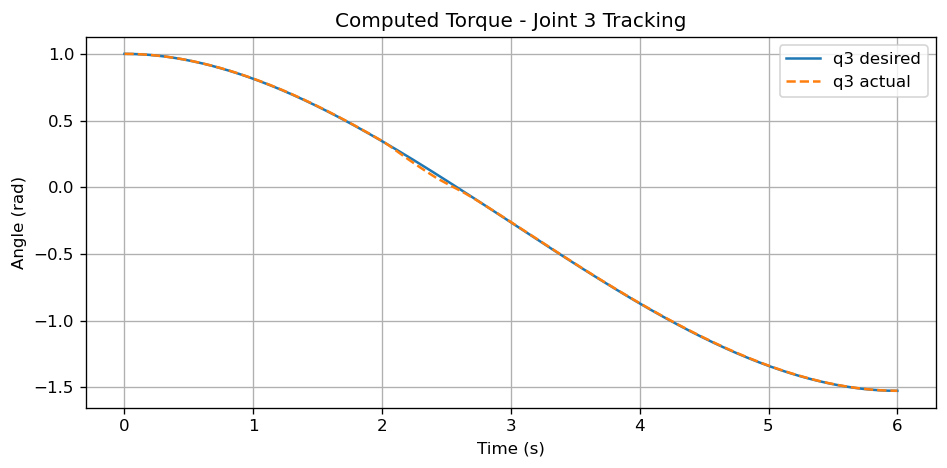

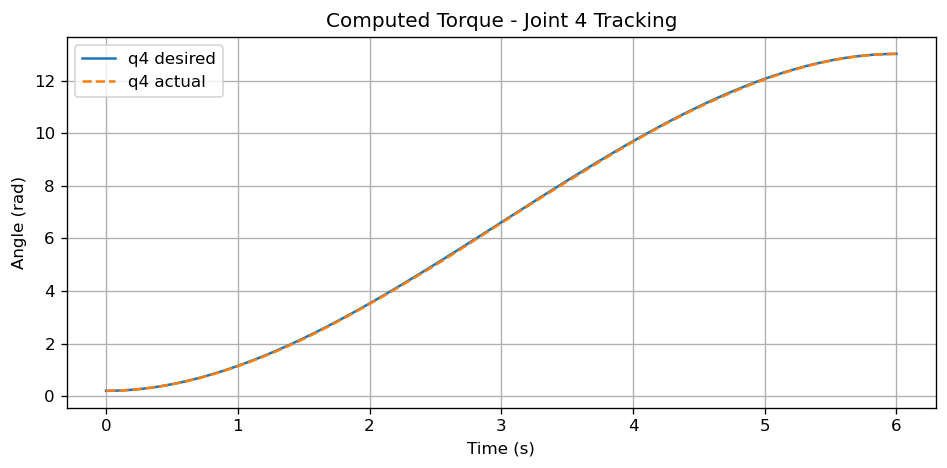

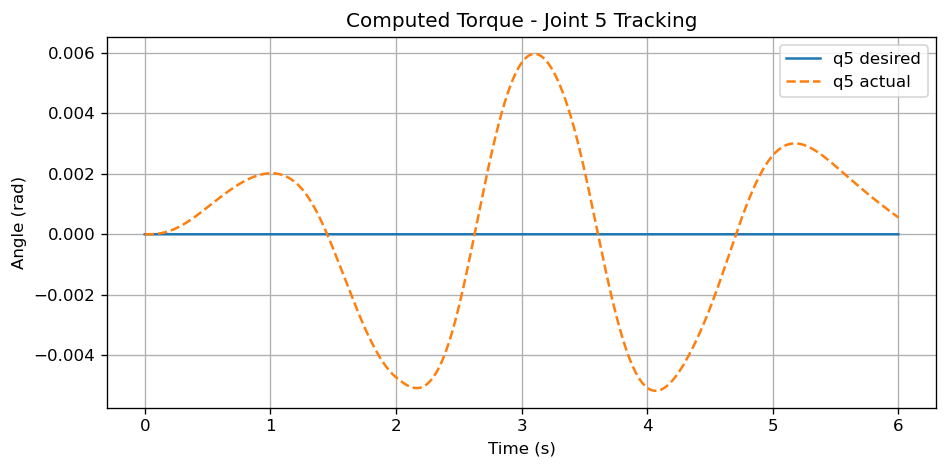

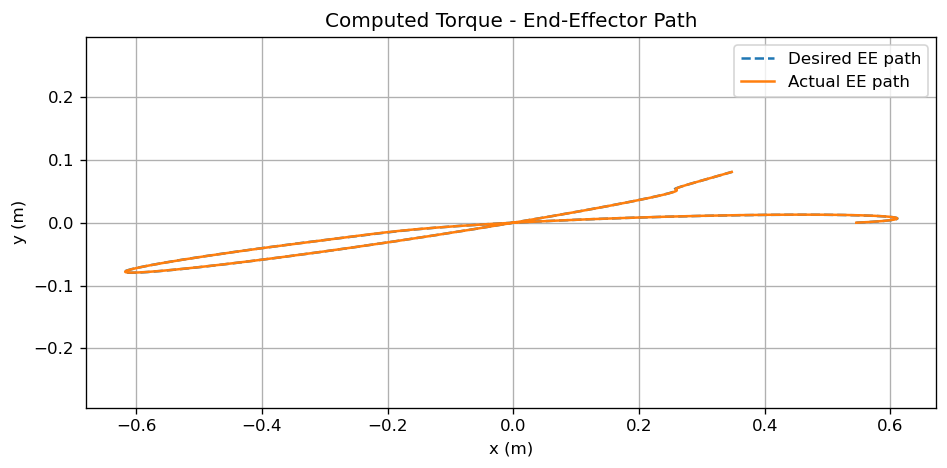

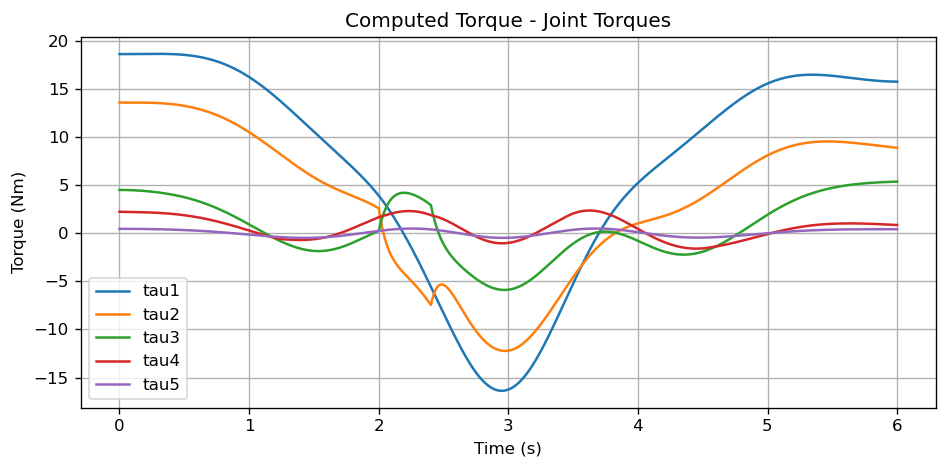

In [53]:
os.makedirs("results", exist_ok=True)
plot_joint_tracking(t, qd, results_pd["q"], "PD")
plot_ee_path(ee_ref, results_pd["ee"], "PD")
plot_torque(t, results_pd["tau"], "PD")

plot_joint_tracking(t, qd, results_pdg["q"], "PD + Gravity")
plot_ee_path(ee_ref, results_pdg["ee"], "PD + Gravity")
plot_torque(t, results_pdg["tau"], "PD + Gravity")

plot_joint_tracking(t, qd, results_ct["q"], "Computed Torque")
plot_ee_path(ee_ref, results_ct["ee"], "Computed Torque")
plot_torque(t, results_ct["tau"], "Computed Torque")